# KAGGLE 2: ENSÉÑAME LA PASTA

En esta competición, evaluaremos la eficacia de los modelos utilizando la métrica Area Under Curve (AUC). Esta métrica proporciona una medida de la capacidad del modelo para discriminar entre clases, siendo especialmente relevante en problemas de clasificación binaria.

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
df = pd.read_csv(r"test.csv")

In [73]:
df.head()

,ID,RevolvingUtilizationOfUnsecuredLines,Age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,129460,1.000000,21,0,8.000000,NaN,0,0,0,0,NaN
1,134018,0.009878,38,0,0.229978,10500.0,10,0,1,0,1.0
2,86523,0.276836,70,0,1914.000000,NaN,23,0,1,0,0.0
3,138466,0.045413,75,0,452.000000,NaN,4,0,0,0,0.0
4,143905,0.000000,82,0,0.000000,NaN,5,0,0,0,0.0


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   ID                                    45000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  45000 non-null  float64
 2   Age                                   45000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  45000 non-null  int64  
 4   DebtRatio                             45000 non-null  float64
 5   MonthlyIncome                         36105 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       45000 non-null  int64  
 7   NumberOfTimes90DaysLate               45000 non-null  int64  
 8   NumberRealEstateLoansOrLines          45000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  45000 non-null  int64  
 10  NumberOfDependents                    43840 non-null  float64
dtypes: float64(4), 

### LIMPIEZA DE DATOS

In [75]:
# quito todas las columnas que tienen NaN en "MonthlyIncome"
df = df.dropna(subset=['MonthlyIncome'])

# no quedan nulos en el resto de columnas :)

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36105 entries, 1 to 44999
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   ID                                    36105 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  36105 non-null  float64
 2   Age                                   36105 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  36105 non-null  int64  
 4   DebtRatio                             36105 non-null  float64
 5   MonthlyIncome                         36105 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       36105 non-null  int64  
 7   NumberOfTimes90DaysLate               36105 non-null  int64  
 8   NumberRealEstateLoansOrLines          36105 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  36105 non-null  int64  
 10  NumberOfDependents                    36105 non-null  float64
dtypes: float64(4), int64

In [77]:
df.describe()

,ID,RevolvingUtilizationOfUnsecuredLines,Age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,36105.000000,36105.000000,36105.000000,36105.000000,36105.000000,36105.000000,36105.000000,36105.000000,36105.000000,36105.000000,36105.000000
mean,75033.587398,7.957090,51.268024,0.416590,25.169346,6592.315718,8.755159,0.245894,1.052735,0.222019,0.853012
std,43270.391621,365.125659,14.445840,3.947764,335.762140,8704.001581,5.210704,3.918468,1.140496,3.902501,1.150378
min,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37437.000000,0.034333,40.000000,0.000000,0.143102,3400.000000,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75153.000000,0.175706,51.000000,0.000000,0.296056,5400.000000,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112516.000000,0.584294,61.000000,0.000000,0.482724,8216.000000,11.000000,0.000000,2.000000,0.000000,2.000000
max,150000.000000,50708.000000,102.000000,98.000000,25033.000000,702500.000000,56.000000,98.000000,32.000000,98.000000,10.000000


* RevolvingUtilizationOfUnsecuredLines

In [78]:
# Mide qué porcentaje del límite de crédito disponible está utilizando una persona
# Es una relación (ratio) que compara el saldo total adeudado en tarjetas de crédito y líneas de crédito personales 
# (excluyendo hipotecas y préstamos para automóviles) con el límite total de crédito disponible.
print(df["RevolvingUtilizationOfUnsecuredLines"].min())
print(df["RevolvingUtilizationOfUnsecuredLines"].max())

# tiene que estar mal, debería estar entre 0 y 1 porque es un porcentaje

0.0
50708.0


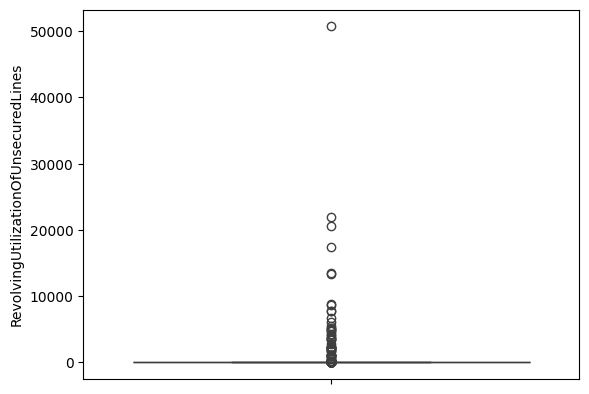

In [79]:
sns.boxplot(df["RevolvingUtilizationOfUnsecuredLines"]);

In [80]:
# leyendo en internet, veo que puede ser algo superior a 1 porque tenga intereses... pero más de 1.3 me parece exagerado

# Ver cuántos valores superan 1.5
mask = df["RevolvingUtilizationOfUnsecuredLines"] > 1.3
print(f"Registros con valor > 1: {mask.sum()} ({mask.mean()*100:.2f}%)")

Registros con valor > 1: 181 (0.50%)


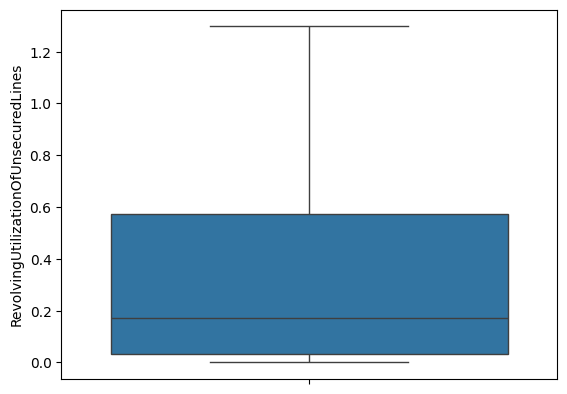

In [81]:
# decido eliminar todo lo que supere 1.3
df = df[df["RevolvingUtilizationOfUnsecuredLines"] <= 1.3]

sns.boxplot(df["RevolvingUtilizationOfUnsecuredLines"]);

In [82]:
print(df["RevolvingUtilizationOfUnsecuredLines"].quantile([0.25, 0.50, 0.75, 0.90])) # hay un salto grande entre Q2 y Q3

0.25    0.033981
0.50    0.173043
0.75    0.573930
0.90    0.968112
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64


In [83]:
# creo una nueva columna que ordene por "grupos" para después hacer ordinalencoder (estilo label encoder pero con orden intrínseco)
df["RevolvingGroup"] = pd.cut(df["RevolvingUtilizationOfUnsecuredLines"],
                               bins=[-1, 0.30, 0.70, 1.0, 1.3],
                               labels=["bajo", "moderado", "alto", "muy_alto"])

In [84]:
from sklearn.preprocessing import OrdinalEncoder
enc_rev = OrdinalEncoder(categories=[["bajo", "moderado", "alto", "muy_alto"]])
df["RevolvingUtilizationOfUnsecuredLines"] = enc_rev.fit_transform(df[["RevolvingGroup"]])

df.drop(columns=["RevolvingGroup"], inplace=True) # elimino la columna que había creado

* AGE:

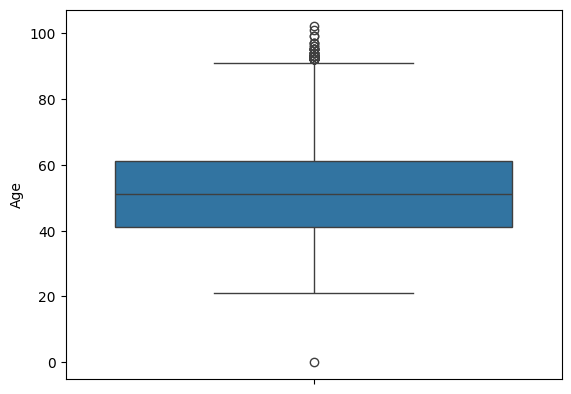

In [85]:
sns.boxplot(df["Age"]);

In [86]:
# min 21, max 103
# ver cuántos superan 90 años

# leyendo en internet, veo que puede ser algo superior a 1 porque tenga intereses... pero más de 1.3 me parece exagerado

# Ver cuántos valores superan 1.5
mask = df["Age"] > 90
print(f"Registros con valor > 90: {mask.sum()} ({mask.mean()*100:.2f}%)")

Registros con valor > 90: 82 (0.23%)


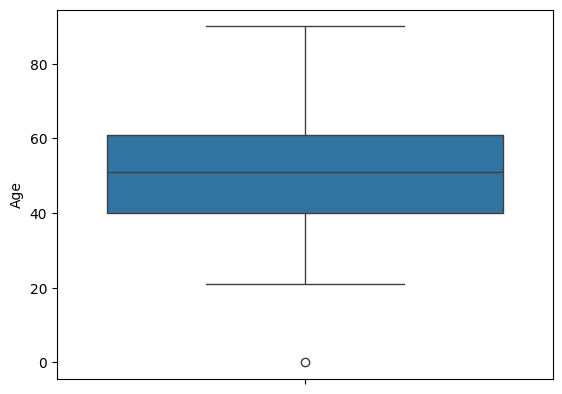

In [87]:
# decido eliminar las edades superiores a 90
df = df[df["Age"] <= 90]

sns.boxplot(df["Age"]);

* NumberOfTime30-59DaysPastDueNotWorse

In [88]:
# Número de veces que el cliente se ha retrasado en el pago de 30 a 59 días, pero sin empeorar en los últimos dos años.
# "Not Worse" (Sin empeorar): Significa que, aunque hubo un retraso, el cliente no se retrasó 60 días o más 
# (no cayó en una mora más grave) en ese periodo.

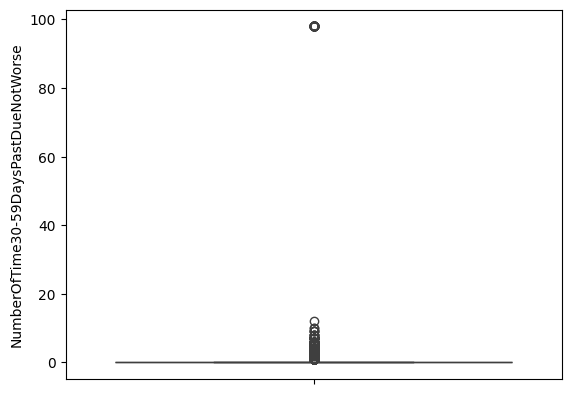

In [89]:
sns.boxplot(df["NumberOfTime30-59DaysPastDueNotWorse"]);

In [90]:
# Ver cuántos valores superan 0
mask = df["NumberOfTime30-59DaysPastDueNotWorse"] > 0
print(f"Registros con valor > 0: {mask.sum()} ({mask.mean()*100:.2f}%)")

Registros con valor > 0: 6005 (16.75%)


In [91]:
# Decido pasarlo a 0 (no se ha retrasado) y 1 (se ha retrasado)
df["NumberOfTime30-59DaysPastDueNotWorse"] = (df["NumberOfTime30-59DaysPastDueNotWorse"] > 0).astype(int)
df["NumberOfTime30-59DaysPastDueNotWorse"].unique()

array([0, 1])

* DebtRatio

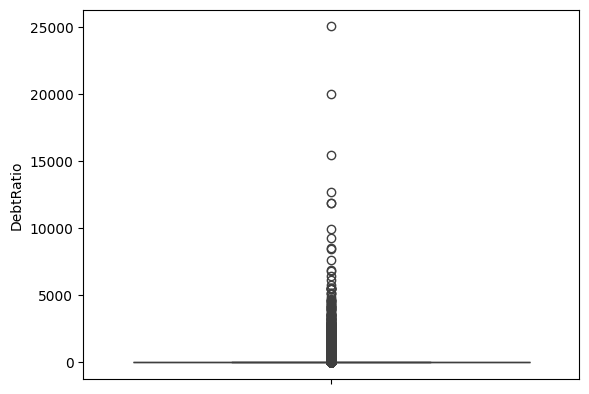

In [92]:
sns.boxplot(df["DebtRatio"]);

In [93]:
# Ver cuántos valores superan 1
mask = df["DebtRatio"] > 2
print(f"Registros con valor > 1: {mask.sum()} ({mask.mean()*100:.2f}%)")

# estos datos son muy heavies... creo que es mejor que los pase con labelencoder tipo "nada", "poco", "medio", "mucho", "extremo"

Registros con valor > 1: 958 (2.67%)


In [94]:
print(df["DebtRatio"].quantile([0.25, 0.50, 0.75, 0.90, 0.95]))

0.25    0.144380
0.50    0.296780
0.75    0.483187
0.90    0.762954
0.95    1.126857
Name: DebtRatio, dtype: float64


In [95]:
# Creo una nueva columna haciendo "grupos" por valores (tipo Label Encoder pero con un orden intrínseco)
df["DebtRatioGroup"] = pd.cut(df["DebtRatio"],
                               bins=[-1, 0.1, 0.35, 1.0, float("inf")],
                               labels=["nada", "poco", "medio", "extremo"])

In [96]:
from sklearn.preprocessing import OrdinalEncoder

enc_debt = OrdinalEncoder(categories=[["nada", "poco", "medio", "extremo"]])
df["DebtRatio"] = enc_debt.fit_transform(df[["DebtRatioGroup"]])

df.drop(columns=["DebtRatioGroup"], inplace=True) # elimino la nueva columna que había creado

In [97]:
df["DebtRatio"].unique()

array([1., 3., 2., 0.])

* MonthlyIncome

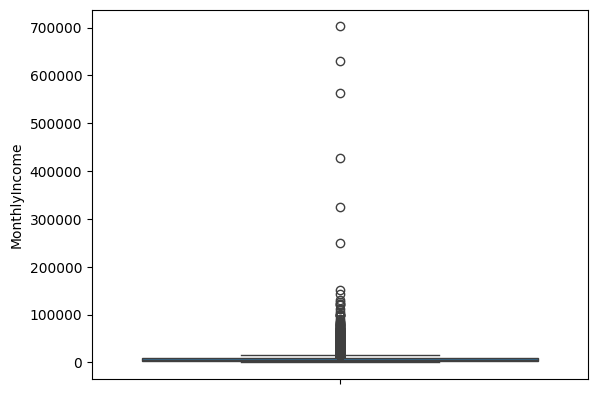

In [98]:
sns.boxplot(df["MonthlyIncome"]);

In [99]:
print(df["MonthlyIncome"].max())
print(df["MonthlyIncome"].min())

702500.0
0.0


In [100]:
print(df["MonthlyIncome"].value_counts(bins=10, sort=False))

(-702.501, 70250.0]     35804
(70250.0, 140500.0]        30
(140500.0, 210750.0]        2
(210750.0, 281000.0]        1
(281000.0, 351250.0]        1
(351250.0, 421500.0]        0
(421500.0, 491750.0]        1
(491750.0, 562000.0]        0
(562000.0, 632250.0]        2
(632250.0, 702500.0]        1
Name: count, dtype: int64


In [101]:
(df["MonthlyIncome"] < 0.1).sum()

np.int64(463)

In [102]:
(df["MonthlyIncome"] < 100000).sum()
# decido eliminar todo lo que pase de 100000 porque son outliers

np.int64(35823)

In [103]:
df = df[df["MonthlyIncome"] <= 100000]

In [104]:
print(df["MonthlyIncome"].value_counts(bins=10, sort=False))

(-100.001, 10000.0]    30460
(10000.0, 20000.0]      4740
(20000.0, 30000.0]       418
(30000.0, 40000.0]        98
(40000.0, 50000.0]        38
(50000.0, 60000.0]        27
(60000.0, 70000.0]        23
(70000.0, 80000.0]        11
(80000.0, 90000.0]         7
(90000.0, 100000.0]        4
Name: count, dtype: int64


* NumberOfOpenCreditLinesAndLoans

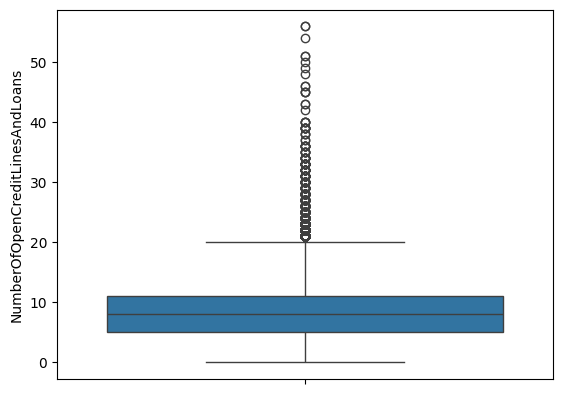

In [105]:
sns.boxplot(df["NumberOfOpenCreditLinesAndLoans"]);

In [106]:
print(df["NumberOfOpenCreditLinesAndLoans"].value_counts(bins=10, sort=False))

(-0.057, 5.6]    10194
(5.6, 11.2]      16772
(11.2, 16.8]      6022
(16.8, 22.4]      2181
(22.4, 28.0]       503
(28.0, 33.6]       101
(33.6, 39.2]        33
(39.2, 44.8]         7
(44.8, 50.4]         8
(50.4, 56.0]         5
Name: count, dtype: int64


In [107]:
# decido dejarla así: hay outliers, pero se pueden manejar

* NumberOfTimes90DaysLate

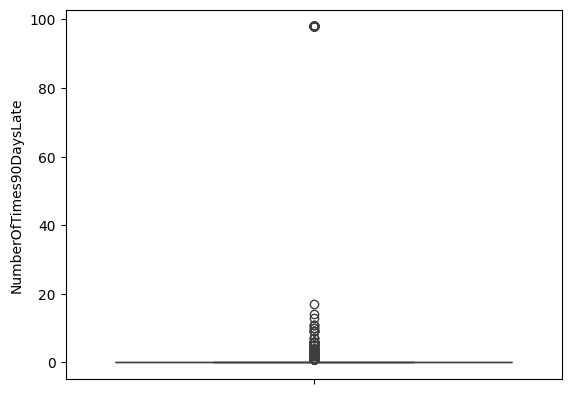

In [108]:
sns.boxplot(df["NumberOfTimes90DaysLate"]);

In [109]:
# Ver cuántos valores superan 0
mask = df["NumberOfTimes90DaysLate"] > 0
print(f"Registros con valor > 0: {mask.sum()} ({mask.mean()*100:.2f}%)")

Registros con valor > 0: 1979 (5.52%)


In [110]:
# Decido pasarlo a 0 (no se ha retrasado) y 1 (se ha retrasado)
df["NumberOfTimes90DaysLate"] = (df["NumberOfTimes90DaysLate"] > 0).astype(int)
df["NumberOfTimes90DaysLate"].unique()

array([0, 1])

* NumberRealEstateLoansOrLines


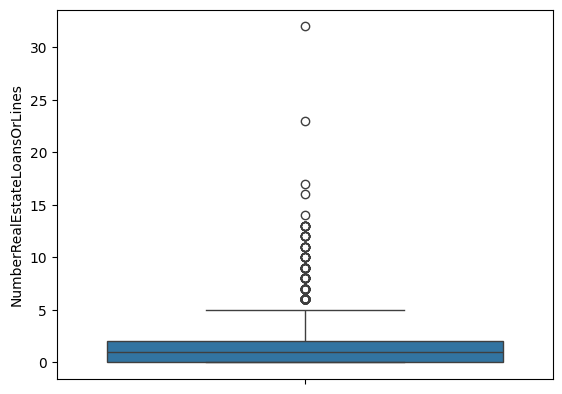

In [111]:
sns.boxplot(df["NumberRealEstateLoansOrLines"]);

In [112]:
print(df["NumberRealEstateLoansOrLines"].value_counts(bins=10, sort=False))

(-0.033, 3.2]    34897
(3.2, 6.4]         811
(6.4, 9.6]          80
(9.6, 12.8]         25
(12.8, 16.0]        10
(16.0, 19.2]         1
(19.2, 22.4]         0
(22.4, 25.6]         1
(25.6, 28.8]         0
(28.8, 32.0]         1
Name: count, dtype: int64


In [113]:
# decido quitar los dos outliers
df = df[df["NumberRealEstateLoansOrLines"] <= 27]

In [114]:
print(df["NumberRealEstateLoansOrLines"].value_counts(bins=10, sort=False))

(-0.024, 2.3]    33342
(2.3, 4.6]        2115
(4.6, 6.9]         251
(6.9, 9.2]          80
(9.2, 11.5]         18
(11.5, 13.8]        15
(13.8, 16.1]         2
(16.1, 18.4]         1
(18.4, 20.7]         0
(20.7, 23.0]         1
Name: count, dtype: int64


* NumberOfTime60-89DaysPastDueNotWorse

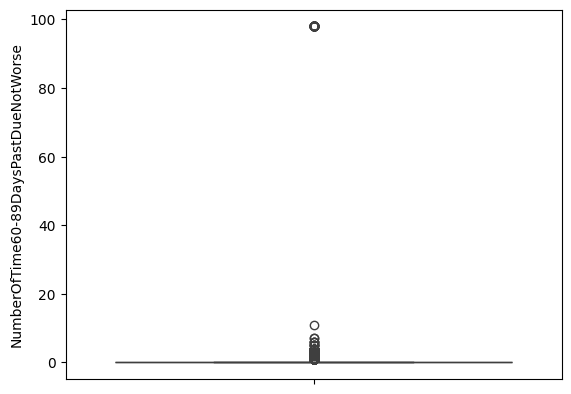

In [115]:
sns.boxplot(df["NumberOfTime60-89DaysPastDueNotWorse"]);

In [116]:
# Ver cuántos valores superan 0
mask = df["NumberOfTime60-89DaysPastDueNotWorse"] > 0
print(f"Registros con valor > 0: {mask.sum()} ({mask.mean()*100:.2f}%)")

Registros con valor > 0: 1860 (5.19%)


In [117]:
# Decido pasarlo a 0 (no se ha retrasado) y 1 (se ha retrasado)
df["NumberOfTime60-89DaysPastDueNotWorse"] = (df["NumberOfTime60-89DaysPastDueNotWorse"] > 0).astype(int)
df["NumberOfTime60-89DaysPastDueNotWorse"].unique()

array([0, 1])

* NumberOfDependents

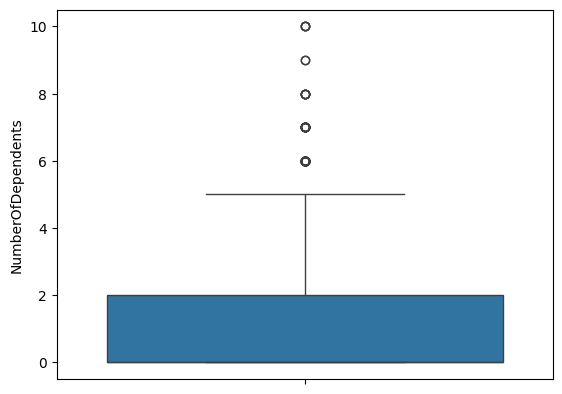

In [118]:
sns.boxplot(df["NumberOfDependents"]);

In [119]:
# Ver cuántos valores superan 5
mask = df["NumberOfDependents"] > 5
print(f"Registros con valor > 5: {mask.sum()} ({mask.mean()*100:.2f}%)")

Registros con valor > 5: 80 (0.22%)


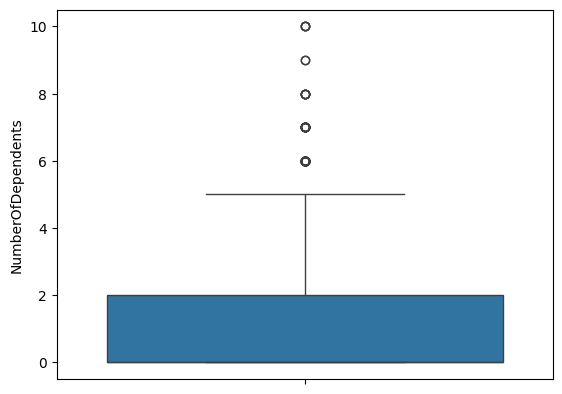

In [120]:
# pruebo quitando mayores de 12
df = df[df["NumberOfDependents"] <= 12]
sns.boxplot(df["NumberOfDependents"]);

In [121]:
df["NumberOfDependents"].unique()

array([ 1.,  0.,  2.,  3.,  4.,  5.,  7.,  8.,  6., 10.,  9.])

# DATASET LIMPIO Y GUARDAR EN CSV:

In [122]:
df.head(25)

,ID,RevolvingUtilizationOfUnsecuredLines,Age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,134018,0.0,38,0,1.0,10500.0,10,0,1,0,1.0
5,118893,2.0,38,0,1.0,1537.0,1,1,0,1,0.0
7,136337,1.0,55,0,3.0,3800.0,20,0,2,0,1.0
8,16700,0.0,28,0,1.0,3046.0,8,0,0,0,0.0
9,57857,2.0,56,0,1.0,10523.0,8,0,3,0,0.0
11,108865,0.0,69,0,2.0,7066.0,14,0,2,0,1.0
12,70643,0.0,57,0,1.0,19892.0,8,0,4,0,0.0
13,63937,0.0,42,0,1.0,2750.0,7,0,0,0,0.0
14,45630,1.0,32,1,3.0,0.0,5,1,0,1,0.0
15,134,0.0,81,0,0.0,2751.0,7,0,0,0,1.0


In [123]:
df.to_csv("test_limpio.csv", index=False)